# DETAILS

# REQUIREMENTS

In [ ]:
!pip install torchmetrics
!pip install opensimplex

In [ ]:
import os
from PIL import Image
import shutil
import random
from pathlib import Path
import torch
import torch.nn.modules as nn
import numpy as np
from torchvision import datasets, transforms
import torch.nn.functional as F
from torchvision.transforms import AutoAugment
from torch.utils.data import DataLoader, random_split, Dataset
from sklearn.model_selection import train_test_split
from diffusers import UNet2DModel
from tqdm.auto import tqdm
from torchvision import models
import torchmetrics
import math
from diffusers.optimization import get_cosine_schedule_with_warmup
from opensimplex import OpenSimplex
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# IMAGE PREPROCESSING

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        
        self.image_names = [
            f for f in os.listdir(folder_path) 
        ]

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder_path, self.image_names[idx])
        
        image = Image.open(img_path).convert("L") 
        
        if self.transform:
            image = self.transform(image)
            
        return image

In [ ]:
no_tumor_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomAffine(
        degrees=2,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02),
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [ ]:
train_dir = '/kaggle/input/datasets/rm1000/brain-tumor-mri-scans/healthy'

full_train_dset = ImageDataset(train_dir, transform = no_tumor_transform)

train_size = int(0.8 * len(full_train_dset))
val_size = len(full_train_dset) - train_size


diff_train_dset, diff_val_dset = random_split(full_train_dset, [train_size, val_size], generator=torch.Generator().manual_seed(42) )

In [ ]:
diff_tloader = DataLoader(diff_train_dset, batch_size=8, shuffle=True)
diff_vloader = DataLoader(diff_val_dset, batch_size=16, shuffle=True)

# DIFFUSION

### NOISE GENERATOR

In [ ]:
def SimplexNoise(
    batch_size,
    height,
    width,
    t_slice,
    octaves=6,
    base_frequency=2**-5,
    decay=0.8,
    device="cpu",
):
    noise_batch = []
    yy, xx = np.meshgrid(np.arange(height), np.arange(width), indexing="ij")

    for b in range(batch_size):
        seed = np.random.randint(0, 1_000_000)
        simplex = OpenSimplex(seed)

        if torch.is_tensor(t_slice) and t_slice.dim() > 0:
            z = float(t_slice[b])
        else:
            z = float(t_slice)

        img_noise = np.zeros((height, width), dtype=np.float32)
        amplitude = 1.0
        frequency = base_frequency

        for _ in range(octaves):
            noise_fn = np.vectorize(simplex.noise3)
            octave_noise = noise_fn(xx * frequency, yy * frequency, z).astype(np.float32)
            img_noise += amplitude * octave_noise
            amplitude *= decay
            frequency *= 2

        img_noise = (img_noise - img_noise.mean()) / (img_noise.std() + 1e-8)
        noise_batch.append(img_noise)

    noise_batch = np.stack(noise_batch, axis=0)
    noise_batch = torch.tensor(noise_batch, dtype=torch.float32, device=device)
    return noise_batch.unsqueeze(1)

### NOISE SCHEDULER


In [ ]:
class NoiseScheduler:

    def __init__(self, num_timesteps, s=0.008):
        self.num_timesteps = num_timesteps

        steps = num_timesteps + 1
        t = torch.linspace(0, num_timesteps, steps)

        f_t = torch.cos(((t / num_timesteps) + s) / (1.0 + s) * math.pi * 0.5) ** 2
        alphas_cum_prod_math = f_t / f_t[0]

        betas = 1.0 - (alphas_cum_prod_math[1:] / alphas_cum_prod_math[:-1])
        self.betas = torch.clip(betas, min=0.0001, max=0.999).float()

        self.alphas = 1.0 - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1.0 - self.alpha_cum_prod)

    def forward_diffusion(self, x0, noise, t):
        batch_size = x0.shape[0]
        req_shape = (batch_size,) + (1,) * (x0.dim() - 1)

        sqrt_alpha_cum_prod = self.sqrt_alpha_cum_prod.to(x0.device)[t].view(req_shape)
        sqrt_one_minus_alpha_cum_prod = self.sqrt_one_minus_alpha_cum_prod.to(x0.device)[t].view(req_shape)

        x_t = sqrt_alpha_cum_prod * x0 + sqrt_one_minus_alpha_cum_prod * noise
        return x_t
    
    '''
    Effective for sampling purposes, proves too noisy and non-deterministic for accurate reconstruction.

    def reverse_timestep(self, x_t, noise_pred, t):
        mean = x_t - ((self.betas.to(x_t.device)[t]) * noise_pred) / (self.sqrt_one_minus_alpha_cum_prod.to(x_t.device)[t])
        mean = mean / torch.sqrt(self.alphas.to(x_t.device)[t])

        if t == 0:
            return mean
        else:
            variance = (1 - self.alpha_cum_prod.to(x_t.device)[t - 1]) / (1.0 - self.alpha_cum_prod.to(x_t.device)[t])
            variance = variance * self.betas.to(x_t.device)[t]
            sigma = variance ** 0.5
            z = SimplexNoise(
              batch_size=x_t.shape[0],
              height=x_t.shape[2],
              width=x_t.shape[3],
              t_slice = t,
              device=device,
            )
            return mean + sigma * z * 0.7
    '''

    def reconstruct(self, x_t, noise_pred, t):
        batch_size = x_t.shape[0]
        req_shape = (batch_size,) + (1,) * (x_t.dim() - 1)

        sqrt_alpha_cum_prod = self.sqrt_alpha_cum_prod.to(x_t.device)[t].view(req_shape)
        sqrt_one_minus_alpha_cum_prod = self.sqrt_one_minus_alpha_cum_prod.to(x_t.device)[t].view(req_shape)

        return (x_t - sqrt_one_minus_alpha_cum_prod * noise_pred) / sqrt_alpha_cum_prod

scheduler = NoiseScheduler(num_timesteps=1000)

## UNET

In [ ]:
unet = UNet2DModel(
    sample_size=128,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(128, 128, 256, 384, 512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
    dropout=0.0,
).to(device)

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)

t_epochs=250
epochs=80

total_training_steps = len(diff_tloader) * t_epochs
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=1500,
    num_training_steps=total_training_steps
)

## TRAINING

In [ ]:
# checkpoint = torch.load("/kaggle/input/models/amoghpanthangi/braid-damage-v1/pytorch/default/1/brain_damage_v1.pth", map_location=device)

# unet.load_state_dict(checkpoint["model_state_dict"])
# optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
# lr_scheduler.load_state_dict(checkpoint["lr_scheduler_state_dict"])

# start_epoch = checkpoint["epoch"] + 1

In [ ]:
def save_checkpoint(epoch, unet, optimizer, lr_scheduler, loss,
                    save_dir="/kaggle/working/", prefix="crddpm_checkpoint"):
    checkpoint_path = f"{save_dir}/{prefix}_ep{epoch}.pth"

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': unet.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'lr_scheduler_state_dict': lr_scheduler.state_dict(),
        'loss': loss.item() if hasattr(loss, "item") else loss
    }

    torch.save(checkpoint, checkpoint_path)
    print(f"Checkpoint saved at {checkpoint_path}")

In [ ]:
prev_val_loss = "N/A"
epoch_bar = tqdm(range(start_epoch, start_epoch+80), desc="Overall Training")

for epoch in epoch_bar:
    unet.train()
    train_loss = 0.0
    training_bar = tqdm(diff_tloader, desc=f"Epoch {epoch+1} Train", leave=False)

    for x_0 in training_bar:
        x_0 = x_0.to(device)
        batch_size = x_0.shape[0]

        timesteps = torch.randint(0, scheduler.num_timesteps, (batch_size,), device=device).long()

        noise = SimplexNoise(
            batch_size=batch_size,
            height=x_0.shape[2],
            width=x_0.shape[3],
            t_slice=timesteps,
            device=device,
        )

        optimizer.zero_grad()
        noisy_images = scheduler.forward_diffusion(x_0, noise, timesteps)
        noise_pred = unet(noisy_images, timesteps).sample

        loss = F.mse_loss(noise_pred, noise)
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(diff_tloader)
    training_bar.set_postfix(Batch_Loss=f"{loss.item():.4f}", Prev_Val=prev_val_loss)

    unet.eval()
    val_loss = 0.0
    validation_bar = tqdm(diff_vloader, desc=f"Epoch {epoch+1} Val", leave=False)

    with torch.no_grad():
        for x_0 in validation_bar:
            x_0 = x_0.to(device)
            batch_size = x_0.shape[0]

            timesteps = torch.randint(0, scheduler.num_timesteps, (batch_size,), device=device).long()

            noise = SimplexNoise(
                batch_size=batch_size,
                height=x_0.shape[2],
                width=x_0.shape[3],
                t_slice=timesteps,
                device=device,
            )

            noisy_images = scheduler.forward_diffusion(x_0, noise, timesteps)
            noise_pred = unet(noisy_images, timesteps).sample

            loss = F.mse_loss(noise_pred, noise)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(diff_vloader)
    prev_val_loss = f"{avg_val_loss:.4f}"
    epoch_bar.set_postfix(Train_Loss=f"{avg_train_loss:.4f}", Val_Loss=f"{avg_val_loss:.4f}")
    if (epoch + 1) % 10 == 0:
        save_checkpoint(
            epoch=epoch + 1,
            unet=unet,
            optimizer=optimizer,
            lr_scheduler=lr_scheduler,
            loss=avg_val_loss
        )

        print(
            f"\nCheckpoint saved at epoch {epoch + 1} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )

print("Training Complete!")

## ANOMALY DETECTION

In [ ]:
def show_single_anomaly_map(image_path, unet, scheduler, t_n, device="cuda"):
    unet.eval()

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    x_0 = transform(Image.open(image_path)).unsqueeze(0).to(device)

    noise = SimplexNoise(
        batch_size=1,
        height=128,
        width=128,
        t_slice=t_n,
        device=device,
    )

    t_tensor = torch.full((1,), t_n, device=device, dtype=torch.long)
    x_t = scheduler.forward_diffusion(x0=x_0, noise=noise, t=t_tensor)

    with torch.no_grad():
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            noise_pred = unet(x_t, t_tensor).sample

        reconstructed = scheduler.reconstruct(x_t, noise_pred, t_tensor)

    amap = (x_0[0] - reconstructed[0]).pow(2)
    amap = amap - amap.min()
    amap = amap / (amap.max() + 1e-8)

    original_np = x_0[0, 0].detach().cpu().numpy()
    reconstructed_np = reconstructed[0, 0].detach().cpu().numpy()
    anomaly_np = amap[0].detach().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original_np, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(reconstructed_np, cmap="gray")
    axes[1].set_title("Reconstructed")
    axes[1].axis("off")

    axes[2].imshow(anomaly_np, cmap="gray")
    axes[2].set_title("Anomaly Map")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

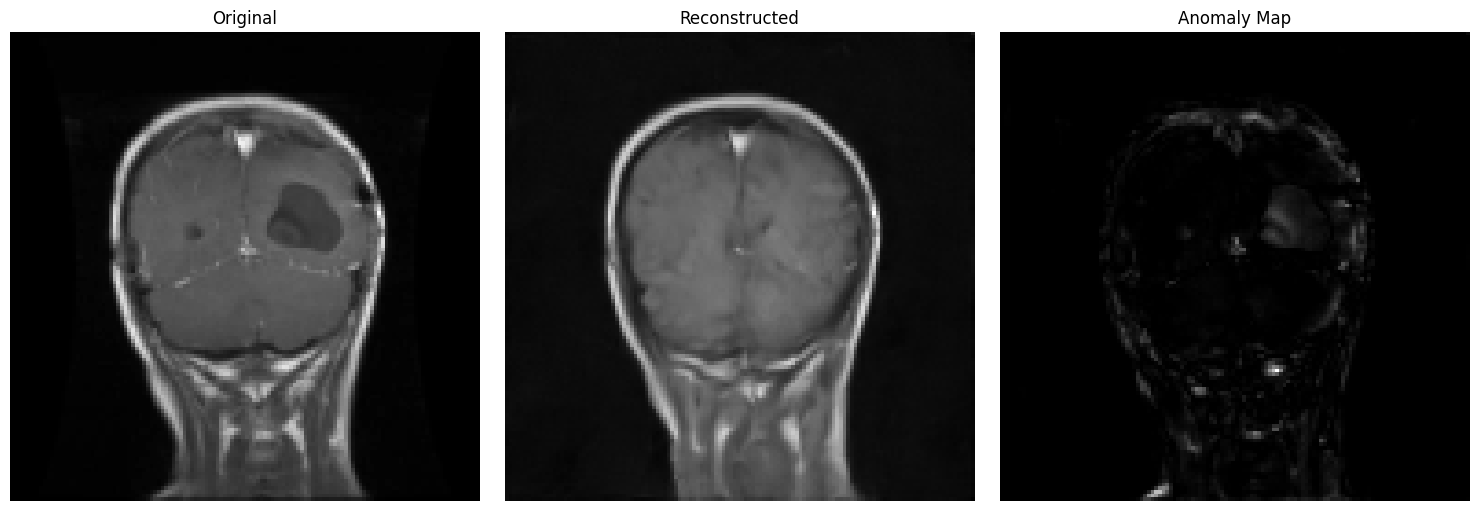

In [341]:
image_path = "/kaggle/input/datasets/rm1000/brain-tumor-mri-scans/glioma/0120.jpg"
show_single_anomaly_map(image_path, unet, scheduler, t_n=200)